# Fit `HGQ-LUT (GNN) — PLF JSC, 32 particles, 3 features` onto `xcau7p-sbvc484-2-e`

Uses **`da4ml.pack.fit_model`** to **physically fit** this model onto the Artix UltraScale+ part **`xcau7p-sbvc484-2-e`** — exact capacity **37,440 LUT / 74,880 FF / 108 BRAM / 216 DSP** (with da4ml's default safety margins). The published baseline is **41,594 LUT**, which **overflows the part by 4,154 LUT (11%)** — so the model *must* offload lookups→BRAM / adders→DSP (bit-exact) to fit, and now **BRAM (108) / DSP (216) are hard caps**, not the reference board's spare headroom.

`fit_model` calibrates a per-model LUT/FF/BRAM/DSP cost model from **3 synth-only
Vivado anchors**, picks the predicate that fits by pure arithmetic (min DSP, then
min BRAM), and — with `confirm=True` — routes the winner once to validate.

Method + model registry live in [`../_fit_common.py`](../_fit_common.py).


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
KEY = NB_DIR.name                       # folder name == model key
if str(NB_DIR.parent) not in sys.path:
    sys.path.insert(0, str(NB_DIR.parent))

import _fit_common as fc
assert KEY in fc.MODELS, (
    f'cwd is {NB_DIR} (folder {KEY!r}); run this notebook from its own model folder. '
    f'Known models: {list(fc.MODELS)}')
cfg = fc.MODELS[KEY]
cap = cfg.part_cap

print(f'Model   : {cfg.title}')
print(f'Part    : {cfg.part_name}  ({cap["lut"]:,} LUT / {cap["ff"]:,} FF / {cap["bram"]} BRAM / {cap["dsp"]} DSP)')
print(f'Baseline: {cfg.baseline_lut:,} LUT (Table III), DSP 0')
if cfg.part_constrained:
    over = cfg.baseline_lut - cap['lut']
    print(f'Target  : physically fit the part (budget {cap["lut"]:,} LUT / {cap["bram"]} BRAM / {cap["dsp"]} DSP, '
          f'default margins) -- baseline overflows by {over:,} LUT ({over / cap["lut"] * 100:.0f}%)')
else:
    print(f'Target  : LUT budget {cfg.lut_budget:,} (0.85x baseline, -15%); FF/BRAM/DSP unconstrained')
print(f'Clock   : {cfg.clock_period} ns   latency cutoff {cfg.latency_cutoff} ns')


Model   : HGQ-LUT (GNN) — PLF JSC, 32 particles, 3 features
Part    : xcau7p-sbvc484-2-e  (37,440 LUT / 74,880 FF / 108 BRAM / 216 DSP)
Baseline: 41,594 LUT (Table III), DSP 0
Target  : physically fit the part (budget 37,440 LUT / 108 BRAM / 216 DSP, default margins) -- baseline overflows by 4,154 LUT (11%)
Clock   : 3 ns   latency cutoff 2.5 ns


## 1) Load + trace → base `comb`

Uses the cached `trace_minmax`'d checkpoint if present, else traces over train+val once and caches it. `fit_model` needs only this `comb`.

In [2]:
comb = fc.load_traced_comb(cfg)


Using cached trace: model_traced_n32_f3.keras
Traced: cost=45896  ops=11241  lookups(op8)=2302  vmul(op7)=0


## 2) `fit_model` — calibrate (3 synth-only runs) → pick → confirm route

In [3]:
result = fc.run_fit(cfg, comb, confirm=True)
print()
print(result.summary())


[vivado] start A0_baseline
[vivado] start A1_bram_max
[vivado] start A2_dsp_cal
[vivado] done A1_bram_max  rc=0  t=202s
[vivado] done A2_dsp_cal  rc=0  t=229s
[vivado] done A0_baseline  rc=0  t=241s
[synth] A0_baseline    LUT*=40170 FF=17613 BRAM=0.0 DSP=0
[synth] A1_bram_max    LUT*=24751 FF=29277 BRAM=483.0 DSP=0
[synth] A2_dsp_cal     LUT*=38803 FF=21069 BRAM=0.0 DSP=216
ResourceModel(part='xcau7p-sbvc484-2-e', clk=3, cutoff=2.5
  LUT*  = 9981 + 0.6578*cost - 0.2083*dsp_adder_cost  (route x0.977)
  FF*   = 11529 + 0.2819*reg_bits  (route x0.999)
  BRAM  = exact RAMB18/RAMB36 tiles from IR geometry
  DSP   = 0.2067 * n_promoted_adders)
[route] fit  LUT=35064 FF=37682 BRAM=58.0 DSP=0  WNS=-0.093 Fmax=323.3MHz  t=400s
FIT: bram(8, 7)_dsp-
  predicted (route): LUT 31963 (85%)  FF 26722 (36%)  BRAM 58.0 (54%)  DSP 0 (0%)  latency 28 cyc
  actual  (1 core): LUT 35064 (+9.7%)  FF 37682 (+41.0%)  BRAM 58.0  DSP 0  Fmax 323.3 MHz

FIT: bram(8, 7)_dsp-
  predicted (route): LUT 31963 (85%)  FF

## 3) Inspect — chosen predicate, predicted front, write artifacts

In [4]:
import pandas as pd
pd.set_option('display.width', 160)

df, info = fc.write_outputs(cfg, result, comb)   # fit_front.csv, result.json, SUMMARY.md

print('feasible :', result.feasible)
if result.feasible:
    print('chosen   :', result.config.name)
    print('predicted:', result.predicted)
    if result.confirm:
        print('confirmed:', result.confirm)
else:
    print('binding  :', result.binding)

a0 = info['a0_predicted_lut']
if a0:
    print(f'\nA0 LUT-only baseline (calibrated): {a0:,.0f}  '
          f'({a0 / cfg.baseline_lut * 100:.0f}% of Table III {cfg.baseline_lut:,})')

fmt = {'lut': '{:.0f}'.format, 'ff': '{:.0f}'.format, 'bram': '{:.1f}'.format,
       'dsp': '{:.0f}'.format, 'latency': '{:.0f}'.format}
print(f'\nPredicted front ({len(df)} candidates; {int(df["fits"].sum())} fit budget):')
print(df.head(16).to_string(index=False, formatters=fmt))


feasible : True
chosen   : bram(8, 7)_dsp-
predicted: ResourceVector(lut=31963.239110269766, ff=26721.524717945616, bram=58.0, dsp=0.0, latency=28)
confirmed: {'lut': 35064.0, 'ff': 37682.0, 'bram': 58.0, 'dsp': 0.0, 'wns': -0.093, 'fmax': 323.31070158422244}

A0 LUT-only baseline (calibrated): 39,246  (94% of Table III 41,594)

Predicted front (77 candidates; 12 fit budget):
         config   lut    ff  bram dsp latency  fits
bram(4, 4)_dsp- 24182 29248 483.0   0      30 False
bram(5, 4)_dsp- 24329 29199 449.5   0      30 False
bram(4, 5)_dsp- 24765 29081 412.5   0      30 False
bram(5, 5)_dsp- 24862 29048 395.0   0      30 False
bram(6, 4)_dsp- 25029 29248 352.5   0      30 False
bram(6, 5)_dsp- 25481 29164 314.5   0      30 False
bram(4, 6)_dsp- 26366 29231 307.5   0      31 False
bram(5, 6)_dsp- 26399 29245 301.5   0      31 False
bram(6, 6)_dsp- 26818 29163 249.5   0      30 False
bram(7, 4)_dsp- 27898 28937 167.0   0      30 False
bram(4, 7)_dsp- 27942 28397 225.0   0      31 Fal

## 4) The LUT↔BRAM trade — predicted front vs the budget

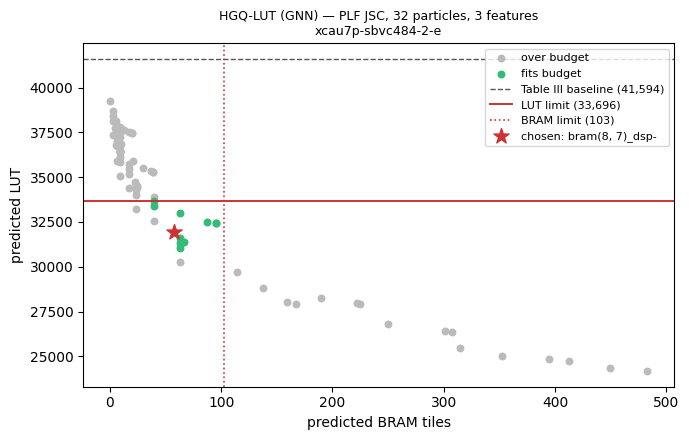

In [5]:
import matplotlib.pyplot as plt

usable = fc.budget_for(cfg).usable()        # the binding limits (after any margins)
fig, ax = plt.subplots(figsize=(7, 4.5))
ok = df[df['fits']]
no = df[~df['fits']]
ax.scatter(no['bram'], no['lut'], s=22, c='#bbb', label='over budget')
ax.scatter(ok['bram'], ok['lut'], s=22, c='#3b7', label='fits budget')
ax.axhline(cfg.baseline_lut, ls='--', c='#555', lw=1, label=f'Table III baseline ({cfg.baseline_lut:,})')
ax.axhline(usable.lut, ls='-', c='#c33', lw=1.4, label=f'LUT limit ({usable.lut:,.0f})')
if cfg.part_constrained:
    ax.axvline(usable.bram, ls=':', c='#c33', lw=1.2, label=f'BRAM limit ({usable.bram:.0f})')
if result.feasible:
    p = result.predicted
    ax.scatter([p.bram], [p.lut], s=130, marker='*', c='#c33', zorder=5, label=f'chosen: {result.config.name}')
ax.set_xlabel('predicted BRAM tiles'); ax.set_ylabel('predicted LUT')
ax.set_title(f'{cfg.title}\n{cfg.part_name}', fontsize=9)
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(NB_DIR / 'fit_front.png', dpi=130)
plt.show()


## 5) `SUMMARY.md`

In [6]:
print((NB_DIR / 'SUMMARY.md').read_text())


# Fit summary — HGQ-LUT (GNN) — PLF JSC, 32 particles, 3 features

- **Part:** `xcau7p-sbvc484-2-e`  (37,440 LUT / 74,880 FF / 108 BRAM / 216 DSP)
- **Published baseline (Table III):** 41,594 LUT, DSP 0
- **Target — physically fit on the part:** budget 37,440 LUT / 108 BRAM / 216 DSP (usable after margins: 33,696 LUT / 103 BRAM / 205 DSP).
  The 41,594-LUT baseline **overflows the part by 4,154 LUT (11%)** — it must offload BRAM/DSP to fit.
- **Clock / latency cutoff:** 3 ns / 2.5 ns

- **A0 baseline (synth-calibrated LUT-only prediction):** 39,246 LUT (94% of Table III)

**FIT:** `bram(8, 7)_dsp-`
- predicted (route): **LUT 31,963** (77% of baseline → −23%), FF 26,722, BRAM 58, DSP 0, latency 28 cyc  [LUT 85% / BRAM 54% / DSP 0% of part]
- confirmed (route): LUT 35,064, FF 37,682, BRAM 58, DSP 0, Fmax 323.3 MHz

